### Biodiversity Project

### Introduction
You are a biodiversity analyst working for the National Parks Service.  You're going to help them analyze some data about species at various national parks.

### Step 1
Import the modules that you'll be using in this assignment:
- matplotlib
- pandas

In [1]:
# Your code here


### Step 2
You have been given a CSV file `species_info.csv` with data about different species in our National Parks, including:
- The scientific name of each species
- The common names of each species
- The species conservation status

Load the dataset and inspect it:
- Load `species_info.csv` into a DataFrame called `species`

What information is contained in the csv?

In [2]:
# Your code here
# URL: https://drive.google.com/u/1/uc?id=1apgJ89cw8UipJYZZqVL4tZVQGUD1Gz_Q&export=download
import pandas as pd
df = pd.read_csv("https://drive.google.com/u/1/uc?id=1apgJ89cw8UipJYZZqVL4tZVQGUD1Gz_Q&export=download")
df

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN
...,...,...,...,...
5819,Vascular Plant,Solanum parishii,Parish's Nightshade,NaN
5820,Vascular Plant,Solanum xanti,"Chaparral Nightshade, Purple Nightshade",NaN
5821,Vascular Plant,Parthenocissus vitacea,"Thicket Creeper, Virginia Creeper, Woodbine",NaN
5822,Vascular Plant,Vitis californica,"California Grape, California Wild Grape",NaN


In [3]:
def agg_common_names(srs):

  splitted = srs.apply(lambda v: v.split(','))
  exploded = splitted.explode()
  stripped = exploded.str.strip()
  unique = stripped.unique()

  return ", ".join(unique)


cleaned_df = df.groupby("scientific_name").agg({
    "category": "first",
    "common_names": agg_common_names,
    "conservation_status": "last"
})

### Step 3
Let's start by learning a bit more about our data.
Question:
1. How many different species are there in the species DataFrame?
2. What are the different values of category in species?
3. What are the different values of conservation_status?

In [4]:
# Your code here
df['category'].value_counts()

category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64

In [5]:
df['conservation_status'].value_counts()

conservation_status
Species of Concern    161
Endangered             16
Threatened             10
In Recovery             4
Name: count, dtype: int64

### Step 4
Let's start doing some analysis!

The column `conservation_status` has several possible values:
- `Species of Concern`: declining or appear to be in need of conservation
- `Threatened`: vulnerable to endangerment in the near future
- `Endangered`: seriously at risk of extinction
- `In Recovery`: formerly `Endangered`, but currnetly neither in danger of extinction throughout all or a significant portion of its range


Instruction:
1. How many species are there in each of these status?

In [6]:
### Your code here
cleaned_df.value_counts('conservation_status')

conservation_status
Species of Concern    151
Endangered             15
Threatened             10
In Recovery             3
Name: count, dtype: int64

In [7]:
cleaned_df['conservation_status'].value_counts()

conservation_status
Species of Concern    151
Endangered             15
Threatened             10
In Recovery             3
Name: count, dtype: int64

Only a small number of them are categorized as needing some sort of protection.  The rest have `conservation_status` equal to `None`.  

*Note: Because `groupby` does not include `None`, we will need to fill in the null values.*

Instruction:
1. Fill the None values with `No Intervention`
2. Rerun the above, then plot the result on a chart


<Axes: >

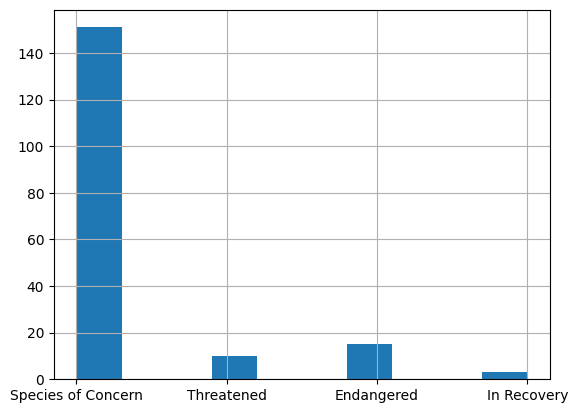

In [8]:
### Your code here
cleaned_df['conservation_status'].hist()

### Step 5
Are certain types of species more likely to be endangered?

Let's create a new column in `species` called `is_protected`, which is
1. `False` if `conservation_status` is equal to `No Intervention`, and
2. `True` otherwise.

In [9]:
### Your code here


Question: How many species on each category is `is_protected`?  Show the result in a pivot table.


In [10]:
### Your code here


Instruction:

Create a new column called `percent_protected`, showing in each category, how many percent of species is `is_protected`.

In [14]:
cleaned_df

,category,common_names,conservation_status,is_protected
scientific_name,,,,
Abies bifolia,Vascular Plant,Rocky Mountain Alpine Fir,None,False
Abies concolor,Vascular Plant,"Balsam Fir, Colorado Fir, Concolor Fir, Silver...",None,False
Abies fraseri,Vascular Plant,Fraser Fir,Species of Concern,True
Abietinella abietina,Nonvascular Plant,Abietinella Moss,None,False
Abronia ammophila,Vascular Plant,"Wyoming Sand Verbena, Yellowstone Sand Verbena",Species of Concern,True
...,...,...,...,...
Zonotrichia leucophrys gambelii,Bird,Gambel's White-Crowned Sparrow,None,False
Zonotrichia leucophrys oriantha,Bird,Mountain White-Crowned Sparrow,None,False
Zonotrichia querula,Bird,Harris's Sparrow,None,False


In [11]:
### Your code here


cleaned_df['is_protected'] = ~cleaned_df['conservation_status'].isna()

summary = cleaned_df.groupby('category').agg({
    "is_protected": ["sum", "count", "mean"]
})

summary

is_protected                
                           sum count      mean
category                                      
Amphibian                    7    79  0.088608
Bird                        75   488  0.153689
Fish                        11   125  0.088000
Mammal                      30   176  0.170455
Nonvascular Plant            5   333  0.015015
Reptile                      5    78  0.064103
Vascular Plant              46  4262  0.010793

In [12]:
summary

is_protected                
                           sum count      mean
category                                      
Amphibian                    7    79  0.088608
Bird                        75   488  0.153689
Fish                        11   125  0.088000
Mammal                      30   176  0.170455
Nonvascular Plant            5   333  0.015015
Reptile                      5    78  0.064103
Vascular Plant              46  4262  0.010793

In [13]:
summary['is_protected', 'sum']/summary['is_protected', 'count']

category
Amphibian            0.088608
Bird                 0.153689
Fish                 0.088000
Mammal               0.170455
Nonvascular Plant    0.015015
Reptile              0.064103
Vascular Plant       0.010793
dtype: float64